# N9 — DeepAgents

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a> 

Este notebook aborda o problema: **como sustentar um agente em uma tarefa que dura dezenas de passos e produz mais informação do que cabe na janela de contexto**.

Os agentes que construímos até aqui funcionam bem em tarefas de poucos passos. Quando a tarefa cresce, eles degradam — não por falta de raciocínio, mas por falta de gestão de contexto. Os *deep agents* são uma resposta a esse problema.

Vamos estudar quatro componentes, e implementar cada um do zero antes de usar a biblioteca pronta:

1. **Ferramenta de planejamento** — o agente escreve e atualiza a própria lista de tarefas;
2. **Sistema de arquivos virtual** — memória fora da janela de contexto;
3. **Subagentes** — delegação com contexto isolado;
4. **Prompt de sistema** — as instruções procedurais que orquestram os três anteriores.

## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- construído grafos com estado, nós, arestas condicionais e ciclos em LangGraph (notebook de Introdução a LangGraph);
- usado reducers para acumular informação no estado, em especial `add_messages` (notebook de Introdução a LangGraph, seção de reducers);
- implementado tools com `@tool` e o padrão ReAct com `bind_tools` (notebook de Ferramentas);
- visto skills como conhecimento procedural em prompt (notebook de Skills);
- implementado Plan-and-Execute e entendido o papel do replanejamento (notebook de Planning).

A partir da seção 9 usaremos a biblioteca `deepagents`, que não foi usada nos notebooks anteriores. Até lá, tudo é construído com LangGraph puro.

## 0.2 Objetivos da aula

Ao final deste notebook, você deverá saber:

1. Explicar por que um agente ReAct simples degrada em tarefas de longo horizonte.
2. Distinguir os quatro componentes de um deep agent e o problema que cada um resolve.
3. Implementar uma ferramenta de planejamento que atualiza o estado com `Command`.
4. Implementar um sistema de arquivos virtual sobre o estado do grafo, com reducer próprio.
5. Descarregar resultados volumosos de tools para arquivos, mantendo o contexto controlado.
6. Delegar subtarefas a subagentes com contexto isolado e sistema de arquivos compartilhado.
7. Medir o efeito do descarregamento de contexto comparando agente raso e deep agent.
8. Usar `create_deep_agent` e escolher entre os backends de sistema de arquivos disponíveis.

## 0.3 Mapa do notebook

Neste notebook, vamos passar por:

1. Premissa da aula: o mesmo loop, outro entorno.
2. A tarefa de longo horizonte.
3. Panorama dos quatro componentes.
4. Componente 1 — Ferramenta de planejamento.
5. Componente 2 — Sistema de arquivos virtual.
6. Componente 3 — Subagentes.
7. Componente 4 — Prompt de sistema.
8. Montando o deep agent do zero.
9. O mesmo com a biblioteca `deepagents`.
10. Backends e persistência.
11. Comparando agente raso e deep agent.
12. Boas práticas.
13. Exercícios de fixação.
14. Resumo da aula.
15. Referências.

## 0.4 Contexto usado nos exemplos

Vamos continuar com o mesmo curso de agentes com LLMs e LangGraph, agora no módulo **A11**.

O cenário motivador desta aula é deliberadamente maior que os anteriores: a aluna **Ana** pede um **guia de revisão completo**, com uma ficha por módulo restante e uma síntese final. A tarefa exige:

- consultar o progresso da aluna;
- descobrir quais módulos ainda faltam;
- ler o material de cada módulo restante;
- produzir uma ficha por módulo;
- sintetizar tudo em um guia final.

Diferente da tarefa do notebook de Planning, aqui o problema não é *decidir a sequência de passos* — a sequência é até bastante óbvia. O problema é que **o material lido não cabe todo na janela de contexto ao mesmo tempo**.

Vamos usar quatro tools ao longo da aula:

- `consultar_progresso_aluno`: já usada nos notebooks de MCP, Skills e Planning;
- `consultar_modulos_restantes`: já usada no notebook de Planning;
- `calcular_carga_total`: já usada nos notebooks de Ferramentas, Skills e Planning;
- `consultar_material_modulo`: **nova tool**, devolve o material didático completo de um módulo — um texto longo, propositalmente volumoso.

A última é a peça central do notebook. É ela que faz o contexto crescer de verdade.

---

## 0.5 Preparação do ambiente

Este notebook assume que você já tem LangChain, LangGraph e um provedor de LLM configurados, como nos notebooks anteriores.

> Importante: os exemplos usam **tool calling** e atualização de estado a partir de tools (`Command`). Escolha um modelo que suporte tool calling e uma versão recente do LangGraph.

In [48]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langchain langchain-core langgraph langchain-openai python-dotenv pydantic rich

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [49]:
from __future__ import annotations

import json
import os
from typing import Annotated, Any, Dict, List, Literal, Optional, TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.chat_models import init_chat_model
from langchain.tools import tool as tool_decorator
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import InjectedToolCallId

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

from IPython.display import Image, display
from rich import print
from rich.markdown import Markdown

Três novidades no bloco de imports, todas ligadas a tools que **modificam o estado do grafo**:

- `Command` (de `langgraph.types`): permite que uma tool devolva uma atualização de estado, e não apenas um texto para o LLM.
- `InjectedState` (de `langgraph.prebuilt`): permite que uma tool leia o estado atual sem que o LLM precise passá-lo como argumento.
- `InjectedToolCallId` (de `langchain_core.tools`): dá à tool acesso ao identificador da chamada, necessário para construir a `ToolMessage` de resposta manualmente.

Argumentos anotados com `Injected...` **não aparecem no schema** que o LLM vê. Do ponto de vista do modelo, `write_file(caminho, conteudo)` tem dois argumentos; do ponto de vista do runtime, tem três.

In [50]:
def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_json(value: Any) -> None:
    """Imprime objetos Python como JSON formatado."""
    print(json.dumps(value, ensure_ascii=False, indent=2))


def print_messages(messages: List[BaseMessage]) -> None:
    """Imprime uma conversa de maneira compacta."""
    for index, message in enumerate(messages):
        print(f"\nMensagem {index} — {message.__class__.__name__}")
        if isinstance(message, AIMessage) and message.tool_calls:
            print("tool_calls:", [c["name"] for c in message.tool_calls])
        else:
            conteudo = str(message.content)
            print(conteudo[:300] + (" [...]" if len(conteudo) > 300 else ""))


def contar_tokens_aproximado(messages: List[BaseMessage]) -> int:
    """Estimativa grosseira de tokens: ~4 caracteres por token.

    Não substitui um tokenizador real, mas é suficiente para comparar
    duas execuções entre si, que é o uso desta aula.
    """
    total_caracteres = 0
    for message in messages:
        total_caracteres += len(str(message.content))
        if isinstance(message, AIMessage) and message.tool_calls:
            total_caracteres += len(json.dumps(message.tool_calls, ensure_ascii=False))
    return total_caracteres // 4

In [51]:
load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)

#from langchain_ollama import ChatOllama
#llm = ChatOllama(model="qwen2.5:32b-instruct-q4_K_M")

Chave OPENAI_API_KEY configurada com sucesso.

### Tools já conhecidas dos notebooks anteriores

As três primeiras tools são as mesmas dos notebooks de Ferramentas, MCP, Skills e Planning. Nenhuma novidade aqui — estão reunidas em uma célula só para não ocupar espaço.

In [52]:
PROGRESSO_ALUNOS = {
    "ana": {"modulo_atual": "A7", "dificuldade_atual": "diferenciar tool local de servidor MCP"},
    "bruno": {"modulo_atual": "A5", "dificuldade_atual": "roteamento condicional com LLM"},
}

MODULOS_DO_CURSO = [
    {"codigo": "A7", "titulo": "Model Context Protocol", "aulas": 4},
    {"codigo": "A8", "titulo": "Skills", "aulas": 3},
    {"codigo": "A9", "titulo": "Raciocínio em agentes", "aulas": 5},
    {"codigo": "A10", "titulo": "Planejamento em agentes", "aulas": 6},
    {"codigo": "A11", "titulo": "DeepAgents", "aulas": 4},
]


@tool_decorator
def consultar_progresso_aluno(nome_aluno: str) -> str:
    """Consulta o módulo atual e a dificuldade relatada de um aluno do curso."""
    chave = nome_aluno.lower()

    if chave not in PROGRESSO_ALUNOS:
        return json.dumps({"erro": "aluno_nao_encontrado", "alunos_disponiveis": list(PROGRESSO_ALUNOS.keys())})

    return json.dumps({"aluno": chave, **PROGRESSO_ALUNOS[chave]}, ensure_ascii=False)


@tool_decorator
def consultar_modulos_restantes(modulo_atual: str) -> str:
    """Lista os módulos restantes do curso a partir de um módulo atual, com a quantidade de aulas de cada um."""
    codigos = [modulo["codigo"] for modulo in MODULOS_DO_CURSO]

    if modulo_atual not in codigos:
        return json.dumps({"erro": "modulo_nao_encontrado", "modulos_disponiveis": codigos})

    restantes = MODULOS_DO_CURSO[codigos.index(modulo_atual):]
    return json.dumps({"modulos_restantes": restantes}, ensure_ascii=False)


@tool_decorator
def calcular_carga_total(quantidade_aulas: int, minutos_por_aula: int = 100) -> str:
    """Calcula a carga horária total a partir da quantidade de aulas e da duração de cada aula."""
    minutos = quantidade_aulas * minutos_por_aula
    return json.dumps({"aulas": quantidade_aulas, "minutos": minutos, "horas": round(minutos / 60, 1)},
                      ensure_ascii=False)

### A tool nova: `consultar_material_modulo`

Esta é a tool que muda o comportamento da aula. Ela devolve o **material didático completo** de um módulo — não um resumo de duas linhas, mas um texto longo, como seria um material real.

É proposital. Se a tool devolvesse pouco texto, o contexto nunca estouraria e todo o resto do notebook seria uma alegoria sem consequência prática.

In [53]:
MATERIAL_MODULOS = {
    "A7": """MÓDULO A7 — MODEL CONTEXT PROTOCOL (MCP)

O Model Context Protocol é um padrão aberto para integração entre agentes, ferramentas e fontes de dados.
Antes do MCP, cada integração entre um agente e uma fonte externa era construída ponto a ponto: para N
agentes e M fontes, o esforço de integração crescia como N vezes M. O MCP introduz uma camada intermediária
padronizada, reduzindo esse esforço para N mais M.

A arquitetura tem três papéis. O host é a aplicação que contém o agente e decide quais servidores conectar.
O cliente MCP é o componente que fala o protocolo com um servidor específico, mantendo a sessão e traduzindo
as chamadas. O servidor MCP expõe recursos de forma padronizada, sem saber nada sobre qual agente está do
outro lado.

O protocolo base é JSON-RPC 2.0. Toda interação começa com um handshake de inicialização, no qual cliente e
servidor negociam a versão do protocolo e anunciam suas capacidades. Só depois dessa negociação o cliente
pode listar e invocar o que o servidor oferece.

Um servidor MCP expõe três tipos de primitiva. Resources são dados identificados por URI, como um documento
ou o resultado de uma consulta; são lidos, não executados. Prompts são templates reutilizáveis, parametrizados,
que encapsulam workflows de interação. Tools são funções invocáveis com efeito, descritas por um schema de
entrada que o agente usa para decidir como chamá-las.

Do ponto de vista de segurança, o MCP assume um modelo de consentimento explícito: o usuário autoriza quais
servidores o host pode conectar, e operações sensíveis devem passar por confirmação. O princípio do menor
privilégio se aplica diretamente — um servidor deve expor apenas o que o agente precisa. Validação de
argumentos no servidor é obrigatória, porque o agente pode produzir chamadas malformadas ou maliciosas.

MCP não substitui o agente nem o framework. Ele padroniza o acesso a recursos externos; a decisão de quando
e por que chamar cada recurso continua sendo do agente, com as técnicas de raciocínio e planejamento que
estudamos nos módulos seguintes.""",

    "A8": """MÓDULO A8 — SKILLS

Skills são capacidades reutilizáveis que encapsulam conhecimento procedural: não o que o agente pode fazer,
mas como ele deve fazer. Enquanto uma tool é uma função executável e o MCP é uma camada de acesso, a skill é
uma instrução sobre procedimento — mais próxima de documentação do que de código.

O problema que as skills resolvem é o inchaço do prompt de sistema. Conforme um agente ganha responsabilidades,
o prompt cresce com instruções procedurais que só são relevantes em situações específicas. Todas elas são
enviadas a cada chamada, custando tokens e diluindo a atenção do modelo.

A anatomia de uma skill tem três partes. Os metadados, ou frontmatter, contêm nome e descrição; a descrição é
o elemento mais importante, porque é a partir dela que o agente decide ativar ou não a skill. O corpo contém
as instruções propriamente ditas, em linguagem natural, no formato de procedimento passo a passo. Recursos
adicionais são arquivos auxiliares que a skill pode referenciar, carregados apenas quando necessário.

O mecanismo que torna isso eficiente é o progressive disclosure, ou divulgação progressiva, em três níveis.
No nível de descoberta, apenas nome e descrição de cada skill estão no contexto — poucas dezenas de tokens
por skill. No nível de ativação, quando o agente decide que uma skill é relevante, o corpo completo é
carregado. No nível de recursos, arquivos auxiliares são lidos apenas se o corpo da skill os referenciar.

Boas práticas na escrita de skills começam pela descrição, que deve dizer com precisão quando a skill se
aplica e quando não se aplica. Instruções devem ser procedurais, não lógica complexa: se o procedimento
envolve cálculo ou controle de fluxo elaborado, provavelmente deveria ser uma tool. Cada skill deve ter uma
responsabilidade única, e deve referenciar explicitamente as tools que utiliza.

Skills, tools e MCP formam três camadas complementares. Tools respondem o que o agente pode fazer. MCP
responde onde o agente pode acessar. Skills respondem como o agente deve fazer.""",

    "A9": """MÓDULO A9 — RACIOCÍNIO EM AGENTES

Raciocínio, em agentes baseados em LLM, é o processo de produzir passos intermediários explícitos antes de
uma resposta ou de uma ação. A distinção fundamental é entre raciocínio implícito, que ocorre dentro da
passagem direta do modelo e não é observável, e raciocínio explícito, que é gerado como texto e pode ser
inspecionado, avaliado e reutilizado.

Few-shot prompting fornece exemplos de entrada e saída no prompt. A variação mais útil para agentes é o
few-shot com raciocínio exposto, no qual os exemplos mostram não apenas a resposta correta, mas o caminho
até ela. O modelo tende a imitar a estrutura do raciocínio, não só o formato da resposta.

Chain-of-Thought instrui o modelo a produzir os passos intermediários antes da conclusão. Em problemas com
estrutura sequencial, melhora consistentemente a acurácia. A implementação moderna usa saída estruturada,
com um campo para o raciocínio e outro para a resposta, evitando parsing de texto livre.

Self-Ask decompõe a pergunta original em subperguntas explícitas, respondendo cada uma antes de sintetizar.
É particularmente útil quando a pergunta esconde dependências que não são óbvias na formulação original.

Self-Consistency gera múltiplas cadeias de raciocínio com temperatura alta e escolhe a resposta mais
frequente. Troca custo por robustez: se o modelo chega à mesma conclusão por caminhos diferentes, a confiança
naquela conclusão aumenta. O custo cresce linearmente com o número de amostras.

ReAct intercala raciocínio e ação, permitindo que observações do ambiente influenciem os passos seguintes.
É a base de praticamente todos os agentes com tools, e continua sendo o padrão para tarefas curtas.

Least-to-Most decompõe o problema em subproblemas ordenados por dependência, resolvendo do mais simples ao
mais complexo, com cada solução alimentando a próxima. Tree of Thoughts explora múltiplos caminhos em
paralelo, avalia cada um e poda os menos promissores.

A escolha da técnica deve seguir o formato do problema, não a moda. Custo e latência crescem rapidamente nas
técnicas que geram múltiplas cadeias.""",

    "A10": """MÓDULO A10 — PLANEJAMENTO EM AGENTES

Planejamento é a capacidade de estruturar a sequência de ações antes ou durante a execução. A diferença
central em relação ao raciocínio é o objeto: raciocínio produz conclusões, planejamento produz sequências de
ações.

ReAct não tem plano explícito. A sequência emerge turno a turno, e cada decisão considera apenas o histórico
acumulado. Isso funciona bem quando o próximo passo depende fortemente do resultado anterior, e mal quando a
tarefa é longa, porque o agente não tem visão de conjunto e pode perder o objetivo no meio do caminho.

Plan-and-Execute separa o agente em três papéis. O planejador olha para a tarefa completa e produz uma lista
de passos antes de qualquer execução. O executor realiza um passo por vez, usando tools quando necessário. O
replanejador, após cada passo, decide se o plano continua válido, se precisa ser ajustado ou se a tarefa já
pode ser finalizada. A vantagem é que o plano existe como objeto explícito, inspecionável e auditável antes
da execução começar.

ReWOO planeja tudo de uma vez, sem observar resultados intermediários, usando variáveis para encadear as
dependências entre passos. Um único planejamento, execução dos passos com substituição de variáveis, e uma
síntese final. É o padrão mais barato em número de chamadas de LLM, e o mais rígido: se o plano estiver
errado, não há oportunidade de correção.

Reflection não é estritamente planejamento de ações, e sim refinamento de conteúdo. Um nó gerador produz uma
saída, um nó crítico a avalia, e o ciclo se repete até um critério de qualidade ser atingido. Aplica-se a
problemas em que a saída é um texto, não uma sequência de ações.

Tree of Thoughts aplicado a planejamento gera múltiplas estratégias candidatas, avalia cada uma e escolhe a
melhor antes de executar. Reduz o risco de se comprometer cedo com uma abordagem ruim, ao custo de várias
chamadas por nível.

O planejamento pode ser estático, quando o plano não é revisado, ou dinâmico, quando é reavaliado a cada
observação. Em qualquer caso, o critério de parada precisa ser explícito.""",

    "A11": """MÓDULO A11 — DEEPAGENTS

Deep agents são agentes projetados para tarefas de longo horizonte temporal. O termo foi popularizado pela
LangChain com a biblioteca deepagents, inspirada no Claude Code, mas o padrão já existia em sistemas como
Deep Research e Manus.

A motivação vem de uma observação empírica: a duração das tarefas que agentes conseguem completar de forma
autônoma vem dobrando a cada poucos meses. Tarefas que levavam minutos passaram a levar horas. E um agente
com loop simples degrada nesse regime — não por limitação de raciocínio, mas por gestão de contexto.

O agente raso mantém todo o seu estado no histórico de mensagens. O histórico é, ao mesmo tempo, a única
memória, o único plano e o único espaço de trabalho. Quatro ausências decorrem disso: sem plano explícito, o
agente perde o objetivo no meio; sem memória externa, o contexto estoura e o que importava sai da janela; sem
delegação, detalhes de subtarefas poluem o contexto principal; sem instruções operacionais, o agente sabe o
que fazer mas não sabe como.

O princípio unificador é o context engineering: a janela de contexto é um recurso finito, e gerenciá-la é o
problema central. Quatro estratégias organizam as soluções: escrever fora da janela, selecionar apenas o
relevante para trazer de volta, comprimir o que já foi feito, e isolar contextos por responsabilidade.

Os quatro componentes do deep agent implementam essas estratégias. O prompt de sistema detalhado carrega o
conhecimento procedural. A ferramenta de planejamento torna o plano um artefato explícito e revisável. O
sistema de arquivos virtual grava fora da janela e relê sob demanda. Os subagentes isolam contextos,
devolvendo ao coordenador apenas o resultado.

O loop permanece o mesmo de sempre. Três dos quatro componentes são apenas tools que o loop pode chamar. O
que muda não é a inteligência do agente, e sim a estrutura em volta dele.""",
}


@tool_decorator
def consultar_material_modulo(codigo_modulo: str) -> str:
    """Consulta o material didático completo de um módulo do curso. Retorna um texto longo."""
    codigo = codigo_modulo.upper()

    if codigo not in MATERIAL_MODULOS:
        return json.dumps({"erro": "modulo_nao_encontrado", "modulos_disponiveis": list(MATERIAL_MODULOS.keys())},
                          ensure_ascii=False)

    return MATERIAL_MODULOS[codigo]


TOOLS_DO_CURSO = [
    consultar_progresso_aluno,
    consultar_modulos_restantes,
    calcular_carga_total,
    consultar_material_modulo,
]

for codigo, texto in MATERIAL_MODULOS.items():
    print(f"{codigo}: {len(texto)} caracteres (~{len(texto) // 4} tokens)")

A7: 2058 caracteres (~514 tokens)

A8: 2045 caracteres (~511 tokens)

A9: 2118 caracteres (~529 tokens)

A10: 2089 caracteres (~522 tokens)

A11: 1897 caracteres (~474 tokens)

# 1. Premissa da aula: o mesmo loop, outro entorno

Antes de qualquer código, vale desfazer uma expectativa comum: **deep agent não é um algoritmo novo**.

O loop continua sendo exatamente o que vimos no notebook de Ferramentas:

```text
pensar → agir → observar → repetir → responder
```

Não existe um "loop profundo". Se você olhar o núcleo de um deep agent, encontra o mesmo ciclo de tool
calling de qualquer agente ReAct.

O que muda é o **entorno** — e, mais especificamente, três dos quatro componentes são apenas tools comuns que
o loop pode chamar:

| Componente | O que é, tecnicamente |
|---|---|
| Prompt de sistema | Uma string mais longa na `SystemMessage` |
| Ferramenta de planejamento | Uma tool que escreve no estado |
| Sistema de arquivos | Duas ou três tools que leem e escrevem no estado |
| Subagentes | Uma tool que, por dentro, roda outro grafo |

O agente não ganhou uma capacidade nova de raciocínio. Ganhou **ferramentas para gerenciar plano, memória e
contexto** — e um prompt que diz quando usá-las.

Essa é a tese do notebook, e vale mantê-la em mente: não é um agente mais inteligente, é o mesmo agente com
andaimes que impedem a degradação.

# 2. A tarefa de longo horizonte

## 2.1 O cenário

A tarefa desta aula é:

> Produza um guia de revisão para a Ana, com uma ficha de estudo por módulo restante e uma síntese final
> indicando por onde começar.

Repare no que ela exige. Consultar o progresso da Ana, descobrir os módulos restantes, ler o material de cada
um, fichar cada material, e sintetizar. São cinco módulos restantes, então pelo menos sete chamadas de tool.

O problema não é a **sequência** — ela é quase óbvia, e um Plan-and-Execute do notebook anterior a resolveria
sem dificuldade. O problema é o **volume**: cada leitura devolve entre 1500 e 2500 caracteres, e todas elas
permanecem no histórico até o fim.

In [54]:
TAREFA_LONGA = (
    "Produza um guia de revisão para a aluna Ana. "
    "Consulte o progresso dela, descubra os módulos restantes, leia o material de cada módulo "
    "e produza uma ficha de estudo por módulo, com os pontos principais. "
    "Ao final, escreva uma síntese indicando por onde ela deve começar."
)

print(TAREFA_LONGA)

Produza um guia de revisão para a aluna Ana. Consulte o progresso dela, descubra os módulos restantes, leia o 
material de cada módulo e produza uma ficha de estudo por módulo, com os pontos principais. Ao final, escreva uma 
síntese indicando por onde ela deve começar.

## 2.2 Rodando o agente raso

Vamos usar exatamente o agente ReAct do notebook de Ferramentas — sem plano, sem arquivos, sem delegação. O
histórico de mensagens é todo o estado que ele tem.

In [55]:
SYSTEM_RASO = """Você é o assistente do curso de agentes com LLMs e LangGraph.
Use as tools disponíveis para cumprir a tarefa do aluno.
Quando tiver informação suficiente, produza a resposta final."""

llm_raso = llm.bind_tools(TOOLS_DO_CURSO)
MAPA_TOOLS = {t.name: t for t in TOOLS_DO_CURSO}


def loop_react_manual(tarefa: str, max_passos: int = 12) -> List[BaseMessage]:
    """Loop ReAct simples: o histórico é o único estado do agente."""
    mensagens: List[BaseMessage] = [SystemMessage(content=SYSTEM_RASO), HumanMessage(content=tarefa)]

    for _ in range(max_passos):
        resposta = llm_raso.invoke(mensagens)
        mensagens.append(resposta)

        if not resposta.tool_calls:
            break

        for chamada in resposta.tool_calls:
            tool = MAPA_TOOLS[chamada["name"]]
            resultado = tool.invoke(chamada["args"])
            mensagens.append(ToolMessage(content=str(resultado), tool_call_id=chamada["id"]))

    return mensagens

In [56]:
mensagens_raso = loop_react_manual(TAREFA_LONGA)

print(f"Mensagens no histórico: {len(mensagens_raso)}")
print(f"Tokens aproximados no contexto final: {contar_tokens_aproximado(mensagens_raso)}")

Mensagens no histórico: 13

Tokens aproximados no contexto final: 3855

## 2.3 Medindo a degradação

Duas medidas importam aqui: quanto o contexto cresceu, e **onde** esse crescimento se concentrou.

In [57]:
def perfil_contexto(mensagens: List[BaseMessage]) -> None:
    """Mostra quanto cada tipo de mensagem contribui para o contexto."""
    por_tipo: Dict[str, int] = {}
    for m in mensagens:
        tipo = m.__class__.__name__
        por_tipo[tipo] = por_tipo.get(tipo, 0) + len(str(m.content))

    total = sum(por_tipo.values()) or 1
    for tipo, caracteres in sorted(por_tipo.items(), key=lambda x: -x[1]):
        print(f"{tipo:16} {caracteres:7} caracteres  ({100 * caracteres // total:3}%)")


perfil_contexto(mensagens_raso)

ToolMessage        10635 caracteres  ( 73%)

AIMessage           3414 caracteres  ( 23%)

HumanMessage         268 caracteres  (  1%)

SystemMessage        180 caracteres  (  1%)

In [58]:
# A resposta final do agente raso
print(Markdown(str(mensagens_raso[-1].content)))

Guia de Revisão para Ana                                                                                           

Módulo A7: Model Context Protocol (MCP)                                                                            

 • Definição: O MCP é um padrão aberto que facilita a integração entre agentes, ferramentas e fontes de dados,     
   reduzindo o esforço de integração.                                                                              
 • Arquitetura:                                                                                                    
    • Host: Aplicação que contém o agente.                                                                         
    • Cliente MCP: Componente que comunica com o servidor.                                                         
    • Servidor MCP: Expõe recursos de forma padronizada.                                                           
 • Interação: Baseada em JSON-RPC 2.0, começa com um handshake de inicialização.                                   
 • Primitivas:                                                                                                     
    • Resources: Dados identificados por URI.                                                                      
    • Prompts: Templates reutilizáveis.                                                                            
    • Tools: Funções invocáveis.                                                                                   
 • Segurança: Modelo de consentimento explícito e validação de argumentos.                                         

Módulo A8: Skills                                                                                                  

 • Definição: Capacidades reutilizáveis que encapsulam conhecimento procedural.                                    
 • Problema Resolvido: Reduz o inchaço do prompt de sistema.                                                       
 • Anatomia de uma Skill:                                                                                          
    • Metadados: Nome e descrição.                                                                                 
    • Corpo: Instruções em formato de procedimento.                                                                
    • Recursos Adicionais: Arquivos auxiliares.                                                                    
 • Mecanismo: Progressive disclosure em três níveis (descoberta, ativação, recursos).                              
 • Boas Práticas: Descrições precisas, instruções procedurais, responsabilidade única.                             

Módulo A9: Raciocínio em Agentes                                                                                   

 • Definição: Processo de produzir passos intermediários explícitos antes de uma resposta.                         
 • Técnicas:                                                                                                       
    • Few-shot prompting: Exemplos com raciocínio exposto.                                                         
    • Chain-of-Thought: Produz passos intermediários.                                                              
    • Self-Ask: Decomposição de perguntas.                                                                         
    • Self-Consistency: Geração de múltiplas cadeias de raciocínio.                                                
    • ReAct: Intercala raciocínio e ação.                                                                          
    • Least-to-Most: Decomposição de problemas.                                                                    
    • Tree of Thoughts: Exploração de múltiplos caminhos.                                                          

Módulo A10: Planejamento em Agentes                                                                                

 • Definição: Estruturação da sequência de ações

## Discussão

O padrão que aparece aqui é o mesmo em qualquer tarefa de leitura: as `ToolMessage` dominam o contexto. O
material dos cinco módulos entra inteiro no histórico e permanece lá até o fim da execução, mesmo depois de
já ter sido processado.

Três consequências práticas:

- **Custo.** O histórico é reenviado a cada chamada. Ler cinco materiais não custa cinco leituras — custa a
  soma acumulada de todas as leituras anteriores em cada nova chamada.
- **Atenção.** Contextos longos sofrem do efeito *lost in the middle*: informação presente no meio do
  histórico é usada com menos frequência do que informação no início ou no fim.
- **Limite.** Com dez módulos em vez de cinco, ou materiais duas vezes maiores, essa execução simplesmente
  não termina.

Note que o agente raso pode até ter produzido uma resposta razoável. A degradação não é abrupta — ela cresce
com o número de passos. Funciona em 5 passos, degrada em 50.

Este resultado é o **baseline** ao qual voltaremos na seção 11.

# 3. Panorama dos quatro componentes

O princípio que organiza os quatro componentes é o **context engineering**: a janela de contexto é um recurso
finito, e gerenciá-la é o problema de projeto central em tarefas longas.

Quatro estratégias, quatro componentes:

| Estratégia | Ideia | Componente |
|---|---|---|
| Escrever | Gravar fora da janela de contexto | Sistema de arquivos |
| Selecionar | Trazer de volta apenas o relevante | Sistema de arquivos |
| Comprimir | Resumir o que já foi feito | Planejamento |
| Isolar | Separar contextos por responsabilidade | Subagentes |

E o prompt de sistema é o que ensina o agente a usar as três primeiras.

```text
                      prompt de sistema
                             ↓
    write_todos  →  [ pensar → agir → observar ]  ←  ls / read_file / write_file
                             ↑
                    delegar_para_subagente
```

Vamos implementar um de cada vez, testando isoladamente, e só depois montar o agente completo.

# 4. Componente 1 — Ferramenta de planejamento

## 4.1 Conceito

No notebook de Planning, o plano era produzido por um **nó do grafo**: o nó planejador rodava, gerava a lista
de passos, e o fluxo seguia. Quem decidia que era hora de planejar era o desenhista do grafo.

Aqui a lógica se inverte. O plano vira uma **tool**, e é o próprio agente que decide quando chamá-la. Isso o
aproxima do planejamento dinâmico da aula anterior, mas sob controle do modelo, não do designer.

A tool `write_todos` escreve a lista de tarefas no estado. Cada item tem uma descrição e um status. O agente
a chama no início para planejar, e novamente a cada progresso para marcar o que concluiu.

```text
LLM decide chamar write_todos
        ↓
Command atualiza state["todos"]
        ↓
ToolMessage confirma ao LLM
        ↓
loop continua, agora com o plano no estado
```

## 4.2 Modelo de um item da lista

Um `TypedDict` simples. O status usa `Literal` para restringir os valores possíveis — mesma prática do
notebook de Introdução a LangGraph.

In [59]:
class Todo(TypedDict):
    descricao: str
    status: Literal["pendente", "em_andamento", "concluida"]


exemplo_todos: List[Todo] = [
    {"descricao": "Consultar progresso da Ana", "status": "concluida"},
    {"descricao": "Ler material do módulo A7", "status": "em_andamento"},
    {"descricao": "Fichar módulo A7", "status": "pendente"},
]

print_json(exemplo_todos)

[
  {
    "descricao": "Consultar progresso da Ana",
    "status": "concluida"
  },
  {
    "descricao": "Ler material do módulo A7",
    "status": "em_andamento"
  },
  {
    "descricao": "Fichar módulo A7",
    "status": "pendente"
  }
]

## 4.3 A tool `write_todos`

Esta é a primeira tool do curso que **modifica o estado do grafo**. Até aqui, todas as nossas tools recebiam
argumentos e devolviam uma string; o resultado virava uma `ToolMessage` e ficava no histórico.

Uma tool que devolve `Command` faz duas coisas ao mesmo tempo: atualiza campos do estado e produz a
`ToolMessage` de resposta. Por isso ela precisa do `tool_call_id` — para construir manualmente a mensagem que
o runtime construiria sozinho.

In [63]:
@tool_decorator
def write_todos(
    todos: List[Todo],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Escreve ou atualiza a lista de tarefas do agente.

    Use no início da tarefa para planejar, e novamente sempre que concluir um passo
    ou perceber que o plano precisa mudar. Cada item tem 'descricao' e 'status'
    ('pendente', 'em_andamento' ou 'concluida').
    """
    resumo = ", ".join(f"{t['descricao']} [{t['status']}]" for t in todos)

    return Command(update={
        "todos": todos,
        "messages": [ToolMessage(
            content=f"Lista de tarefas atualizada com {len(todos)} itens: {resumo}",
            tool_call_id=tool_call_id,
        )],
    })

PydanticUserError: Please use `typing_extensions.TypedDict` instead of `typing.TypedDict` on Python < 3.12.

For further information visit https://errors.pydantic.dev/2.13/u/typed-dict-version

Repare no schema que o LLM enxerga: `tool_call_id` **não aparece**, porque está anotado com
`InjectedToolCallId`. Do ponto de vista do modelo, `write_todos` tem um único argumento.

In [61]:
print("Nome da tool:", write_todos.name)
print("Argumentos visíveis ao LLM:", list(write_todos.args.keys()))

NameError: name 'write_todos' is not defined

## 4.4 O estado com plano

Por enquanto, um estado mínimo com `messages` e `todos`. Ele vai crescer nas próximas seções.

In [ ]:
class EstadoComPlano(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    todos: List[Todo]

## 4.5 Testando a tool isoladamente

Antes de montar o grafo, vale ver o `Command` que a tool produz. Ele é apenas um objeto com um dicionário de
atualização — nada de mágico.

Um detalhe de invocação que vale conhecer, porque é fonte comum de erro: uma tool que declara
`InjectedToolCallId` **não pode ser invocada com um dicionário simples de argumentos**. Ela precisa receber um
`ToolCall` completo, no mesmo formato que o LLM produz:

```python
{"name": "...", "args": {...}, "id": "...", "type": "tool_call"}
```

É desse `id` que o `tool_call_id` é extraído. Dentro do grafo isso é automático — cada item de
`message.tool_calls` já vem nesse formato.

In [ ]:
chamada_simulada = {
    "name": "write_todos",
    "args": {"todos": [
        {"descricao": "Ler material do A7", "status": "pendente"},
        {"descricao": "Fichar o A7", "status": "pendente"},
    ]},
    "id": "chamada-teste-1",
    "type": "tool_call",
}

comando = write_todos.run(
    {
        "todos": [
            {
                "descricao": "Pesquisar Deep Agents",
                "status": "pendente",
            }
        ]
    },
    tool_call_id="call_123",
)


print("Tipo devolvido:", type(comando).__name__)
print("Campos atualizados:", list(comando.update.keys()))
print("Conteúdo da ToolMessage:", comando.update["messages"][0].content)

Tipo devolvido: Command

Campos atualizados:
['todos', 'messages']

Conteúdo da ToolMessage: Lista de tarefas atualizada com 1 itens: Pesquisar Deep Agents

## Discussão

O ganho aqui não é o modelo "planejar melhor" — LLMs já produzem listas de passos sem nenhuma ferramenta. O
ganho é o plano deixar de ser texto solto no histórico e virar um **campo estruturado do estado**.

Isso muda três coisas na prática. O plano fica inspecionável: dá para logar, exibir ao usuário, ou exigir
aprovação humana antes de executar. Fica revisável: o agente pode reescrevê-lo sem que a versão antiga
desapareça do histórico e cause confusão. E fica sobrevivente à compressão: se você truncar mensagens antigas
para economizar contexto, o plano continua no estado.

Uma falha real e frequente: o agente marca uma tarefa como concluída sem tê-la executado. Não há nada na
ferramenta que impeça isso — a defesa fica no prompt de sistema, e voltaremos a ela na seção 7.

# 5. Componente 2 — Sistema de arquivos virtual

## 5.1 Conceito

A ideia é simular um sistema de arquivos dentro do estado do LangGraph, usando um dicionário simples: a chave
é o caminho do arquivo, o valor é o conteúdo.

Isso dá persistência de curto prazo, no escopo da thread — ideal para manter contexto dentro de uma execução,
mas não para informação que precisa sobreviver entre conversas diferentes. Na seção 10 veremos como trocar
esse comportamento sem mudar nada no agente.

O ganho é o **descarregamento de contexto** (*context offloading*): em vez de manter o resultado inteiro de
cada tool no histórico, o agente grava o resultado em um arquivo e mantém no contexto apenas o caminho e um
resumo curto. Quando precisar do conteúdo de novo, relê.

```text
sem arquivos:   contexto = [resultado 1][resultado 2][resultado 3][resultado 4] ...
com arquivos:   contexto = [/a7.md ✓][/a8.md ✓][/a9.md ✓] + leitura sob demanda
```

## 5.2 O reducer do sistema de arquivos

O campo `files` precisa **acumular** entre atualizações, e não ser sobrescrito. Se cada nó devolvesse o
dicionário inteiro, um nó que grava um arquivo apagaria todos os outros.

O reducer resolve isso. `left` são os arquivos já existentes no estado, `right` são os novos valores. A
expressão `{**left, **right}` desempacota primeiro `left` e depois `right`, de modo que chaves repetidas em
`right` sobrescrevem as de `left` — que é exatamente o comportamento esperado ao regravar um arquivo.

In [ ]:
def file_reducer(left: Optional[Dict[str, str]], right: Optional[Dict[str, str]]) -> Dict[str, str]:
    """Combina o dicionário de arquivos existente com as novas gravações."""
    if left is None:
        return right or {}
    if right is None:
        return left
    return {**left, **right}


# Demonstração do comportamento
antes = {"/notas.md": "conteúdo antigo", "/plano.md": "plano"}
novo = {"/notas.md": "conteúdo NOVO", "/ficha.md": "ficha"}

print_json(file_reducer(antes, novo))

{
  "/notas.md": "conteúdo NOVO",
  "/plano.md": "plano",
  "/ficha.md": "ficha"
}

## 5.3 O estado com arquivos

Agora o estado tem os três campos que acompanharão o agente até o fim do notebook.

In [ ]:
class DeepAgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    todos: List[Todo]
    files: Annotated[Dict[str, str], file_reducer]

## 5.4 As tools de arquivo

Três tools: `ls` lista, `read_file` lê, `write_file` grava.

As duas primeiras apenas **leem** o estado, então usam `InjectedState` e devolvem string normalmente. A
terceira **modifica** o estado, então devolve `Command`, como o `write_todos`.

As tools de leitura e escrita trabalham com texto simples delimitado por quebras de linha.

In [ ]:
@tool_decorator
def ls(state: Annotated[dict, InjectedState]) -> str:
    """Lista os arquivos disponíveis no sistema de arquivos virtual."""
    arquivos = state.get("files") or {}

    if not arquivos:
        return "Nenhum arquivo gravado ainda."

    linhas = [f"{caminho} ({len(conteudo)} caracteres)" for caminho, conteudo in sorted(arquivos.items())]
    return "\n".join(linhas)


@tool_decorator
def read_file(caminho: str, state: Annotated[dict, InjectedState]) -> str:
    """Lê o conteúdo de um arquivo do sistema de arquivos virtual."""
    arquivos = state.get("files") or {}

    if caminho not in arquivos:
        disponiveis = ", ".join(sorted(arquivos.keys())) or "nenhum"
        return f"Erro: arquivo '{caminho}' não encontrado. Arquivos disponíveis: {disponiveis}"

    return arquivos[caminho]


@tool_decorator
def write_file(
    caminho: str,
    conteudo: str,
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Grava conteúdo em um arquivo do sistema de arquivos virtual.

    Use para guardar resultados longos fora do contexto da conversa.
    Se o arquivo já existir, o conteúdo é substituído.
    """
    return Command(update={
        "files": {caminho: conteudo},
        "messages": [ToolMessage(
            content=f"Arquivo '{caminho}' gravado com {len(conteudo)} caracteres.",
            tool_call_id=tool_call_id,
        )],
    })

## 5.5 Testando as tools de arquivo

Como `ls` e `read_file` dependem do estado, precisamos passá-lo explicitamente ao invocá-las fora do grafo.
Dentro do grafo isso é automático.

In [ ]:
estado_simulado = {"files": {"/fichas/a7.md": "Ficha do módulo A7: MCP padroniza o acesso a recursos."}}

print("--- ls ---")
print(ls.invoke({"state": estado_simulado}))

print("\n--- read_file (arquivo existente) ---")
print(read_file.invoke({"caminho": "/fichas/a7.md", "state": estado_simulado}))

print("\n--- read_file (arquivo inexistente) ---")
print(read_file.invoke({"caminho": "/fichas/a99.md", "state": estado_simulado}))

--- ls ---

/fichas/a7.md (54 caracteres)

--- read_file (arquivo existente) ---

Ficha do módulo A7: MCP padroniza o acesso a recursos.

--- read_file (arquivo inexistente) ---

Erro: arquivo '/fichas/a99.md' não encontrado. Arquivos disponíveis: /fichas/a7.md

# 6. Componente 3 — Subagentes

## 6.1 Conceito

A topologia aqui é a mesma que vimos no padrão Supervisor: um agente coordenador delega subtarefas a agentes
especializados. O que muda é o **argumento**.

No padrão Supervisor, a razão para delegar é modularidade — separar responsabilidades, cada agente com suas
tools e seu prompt. Aqui a razão é contexto: o subagente executa em uma janela própria, e apenas o
**resultado** volta ao coordenador. Os passos intermediários nunca entram no contexto principal.

```text
coordenador                          subagente leitor
    │                                       │
    ├── delegar("A7") ────────────────────► │  [contexto próprio, vazio]
    │                                       │  lê material (2000 chars)
    │                                       │  produz ficha (300 chars)
    │ ◄──────────────── ficha (300 chars) ──┤
    │                                       │
  contexto recebeu 300, não 2300
```

Isso é o que evita o efeito "telefone sem fio": a informação não se degrada ao passar por múltiplos agentes,
porque o conteúdo bruto fica gravado no sistema de arquivos e o que trafega é uma referência mais um resumo.

Um ponto contraintuitivo e importante: **subagentes isolam contexto, não arquivos.** O sistema de arquivos é
compartilhado. É justamente por isso que a delegação funciona — o subagente grava o resultado onde o
coordenador consegue ler depois.

## 6.2 O subagente leitor

O subagente é um grafo completo, com prompt próprio e conjunto próprio de tools. Ele não vê o histórico do
coordenador; começa com o contexto vazio.

Para manter o exemplo enxuto, o leitor tem apenas duas tools: ler o material e gravar a ficha.

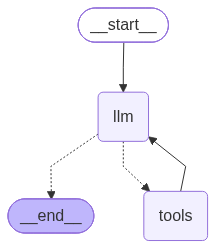

In [ ]:
SYSTEM_LEITOR = """Você é um agente leitor especializado do curso de agentes com LLMs.

Sua única tarefa é ler o material de UM módulo e produzir uma ficha de estudo curta.

Procedimento:
1. Use read_file para ler o material do módulo indicado.
2. Produza uma ficha com no máximo 5 tópicos, cada um em uma linha começando por "- ".
3. Use write_file para gravar a ficha no caminho indicado.
4. Responda com uma única frase confirmando que a ficha foi gravada.

Nunca reproduza o material completo na sua resposta. A ficha é um resumo."""

tools_leitor = [read_file, write_file]
llm_leitor = llm.bind_tools(tools_leitor)
mapa_tools_leitor = {t.name: t for t in tools_leitor}


def no_llm_leitor(state: DeepAgentState):
    mensagens = [SystemMessage(content=SYSTEM_LEITOR)] + state["messages"]
    return {"messages": [llm_leitor.invoke(mensagens)]}


def no_tools_leitor(state: DeepAgentState):
    ultima = state["messages"][-1]
    atualizacoes: Dict[str, Any] = {"messages": [], "files": {}}

    for chamada in ultima.tool_calls:
        chamada_completa = dict(chamada)
        if chamada["name"] == "read_file":
            chamada_completa["args"] = {**chamada["args"], "state": state}

        resultado = mapa_tools_leitor[chamada["name"]].invoke(chamada_completa)

        if isinstance(resultado, Command):  # write_file
            atualizacoes["files"].update(resultado.update.get("files", {}))
            atualizacoes["messages"].extend(resultado.update.get("messages", []))
        else:  # read_file já devolve uma ToolMessage
            atualizacoes["messages"].append(resultado)

    return atualizacoes


def rotear_leitor(state: DeepAgentState) -> Literal["tools", "__end__"]:
    ultima = state["messages"][-1]
    return "tools" if getattr(ultima, "tool_calls", None) else END


builder = StateGraph(DeepAgentState)
builder.add_node("llm", no_llm_leitor)
builder.add_node("tools", no_tools_leitor)
builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", rotear_leitor, {"tools": "tools", END: END})
builder.add_edge("tools", "llm")

subagente_leitor = builder.compile()
display_graph(subagente_leitor)

## 6.3 A tool de delegação

Do ponto de vista do coordenador, o subagente inteiro é **uma tool**. Ela recebe o módulo, executa o grafo do
leitor em um contexto novo, e devolve apenas a última mensagem.

Repare no detalhe que faz a delegação funcionar: a tool passa `state["files"]` para o subagente e recolhe os
arquivos de volta. O contexto (`messages`) é descartado; os arquivos, não.

In [ ]:
@tool_decorator
def delegar_leitura(
    codigo_modulo: str,
    state: Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Delega a leitura e o fichamento de um módulo a um subagente especializado.

    O subagente lê o material e grava a ficha. Apenas uma confirmação curta
    volta para esta conversa — o material completo não entra no contexto.
    """
    codigo = codigo_modulo.upper()
    caminho_material = f"/material/{codigo.lower()}.md"
    caminho_ficha = f"/fichas/{codigo.lower()}.md"

    instrucao = (
        f"Leia o arquivo '{caminho_material}' e produza a ficha de estudo do módulo {codigo}. "
        f"Grave a ficha em '{caminho_ficha}'."
    )

    resultado = subagente_leitor.invoke({
        "messages": [HumanMessage(content=instrucao)],
        "files": state.get("files") or {},
        "todos": [],
    })

    resposta_subagente = str(resultado["messages"][-1].content)

    return Command(update={
        # Os arquivos voltam: o sistema de arquivos é COMPARTILHADO.
        "files": resultado.get("files") or {},
        # O histórico do subagente NÃO volta: o contexto é ISOLADO.
        "messages": [ToolMessage(
            content=f"Subagente leitor concluiu o módulo {codigo}. {resposta_subagente}",
            tool_call_id=tool_call_id,
        )],
    })

## 6.4 Demonstrando o isolamento

Vamos rodar o subagente diretamente e comparar dois números: quanto contexto ele consumiu por dentro, e
quanto voltaria para o coordenador.

In [ ]:
estado_com_material = {
    "messages": [HumanMessage(content="Leia o arquivo '/material/a7.md' e produza a ficha do módulo A7. "
                                      "Grave a ficha em '/fichas/a7.md'.")],
    "files": {"/material/a7.md": MATERIAL_MODULOS["A7"]},
    "todos": [],
}

resultado_sub = subagente_leitor.invoke(estado_com_material)

print("=== DENTRO do subagente ===")
print(f"Mensagens no histórico: {len(resultado_sub['messages'])}")
print(f"Tokens aproximados:     {contar_tokens_aproximado(resultado_sub['messages'])}")

print("\n=== O que VOLTA para o coordenador ===")
resposta_final = str(resultado_sub["messages"][-1].content)
print(f"Caracteres: {len(resposta_final)}")
print(resposta_final)

print("\n=== Arquivos COMPARTILHADOS após a delegação ===")
for caminho in sorted(resultado_sub["files"]):
    print(f"  {caminho} ({len(resultado_sub['files'][caminho])} caracteres)")

=== DENTRO do subagente ===

Mensagens no histórico: 6

Tokens aproximados:     735

=== O que VOLTA para o coordenador ===

Caracteres: 56

A ficha para o módulo A7 foi gravada em '/fichas/a7.md'.

=== Arquivos COMPARTILHADOS após a delegação ===

/fichas/a7.md (400 caracteres)

/material/a7.md (2058 caracteres)

In [ ]:
print(Markdown(resultado_sub["files"].get("/fichas/a7.md", "(ficha não gravada)")))

 • Model Context Protocol (MCP) é um padrão aberto para integração entre agentes e fontes de dados                 
 • Arquitetura MCP tem três papéis: host, cliente MCP e servidor MCP                                               
 • O protocolo base do MCP é JSON-RPC 2.0 com handshake de inicialização                                           
 • Um servidor MCP expõe primitivas em três categorias: Resources, Prompts e Tools                                 
 • MCP segue um modelo de consentimento explícito e princípio do menor privilégio

## Discussão

Os dois números da célula anterior contam a história inteira: o subagente consumiu alguns milhares de tokens
para produzir algumas centenas de caracteres de ficha, e só esses caracteres voltaram ao coordenador.
Multiplicando por cinco módulos, a economia no contexto principal é substancial.

E a lista de arquivos ao final mostra o outro lado: `/fichas/a7.md` existe agora no estado devolvido, embora
o coordenador nunca tenha visto o texto do material. Contexto isolado, arquivos compartilhados.

Duas ressalvas honestas sobre este exemplo. Primeiro, ele é **sequencial** — implementações reais delegam
subagentes em paralelo, que é onde o ganho de latência aparece. Segundo, o isolamento tem um custo de
qualidade: o coordenador confia na ficha sem ter lido o material. Se o subagente omitir algo essencial, o
coordenador não tem como saber. É o trade-off central da delegação.

Vale também demarcar o escopo: aqui tratamos subagentes como **mecanismo de isolamento de contexto**.
Coordenação entre agentes autônomos, protocolos de comunicação e organização de papéis são o tema dos
módulos de sistemas multiagentes, mais adiante no curso.

# 7. Componente 4 — Prompt de sistema

## 7.1 Conceito

Os três componentes anteriores são tools. Elas existem, funcionam, e o agente pode chamá-las — mas nada
garante que ele **vai** chamá-las, nem na ordem certa.

O prompt de sistema é o que fecha essa lacuna. Ele não é uma frase de papel do tipo "você é um assistente
útil": é um documento procedural que diz quando planejar, quando gravar, quando delegar e quando ler.

Isso é exatamente o conhecimento procedural do notebook de Skills, agora aplicado ao próprio funcionamento do
agente. Em implementações reais o prompt de sistema de um deep agent tem milhares de tokens — e a biblioteca
`deepagents` incorporou skills como primitiva justamente para modularizar esse volume.

## 7.2 O prompt do harness

Quatro blocos: papel, ferramentas de gestão, procedimento e regras. A última regra existe por um motivo
específico, comentado logo abaixo.

In [ ]:
SYSTEM_DEEP_AGENT = """Você é o assistente do curso de agentes com LLMs e LangGraph.

Você trabalha em tarefas longas, que exigem muitos passos. Além das tools do curso, você tem
ferramentas para gerenciar seu próprio trabalho:

- write_todos: escreve e atualiza sua lista de tarefas.
- carregar_material_em_arquivo: baixa o material de um módulo para um arquivo, sem poluir a conversa.
- delegar_leitura: entrega a leitura e o fichamento de um módulo a um subagente especializado.
- ls, read_file, write_file: listam, leem e gravam arquivos.

PROCEDIMENTO
1. Antes de agir, escreva a lista de tarefas com write_todos.
2. Use as tools do curso para levantar as informações estruturais (progresso, módulos, carga).
3. Para cada módulo restante: carregue o material em arquivo e delegue a leitura ao subagente.
4. Marque cada item como concluído imediatamente após concluí-lo, chamando write_todos de novo.
5. Ao final, leia as fichas com read_file e escreva a síntese.

REGRAS
- Nunca traga o material completo de um módulo para a conversa: use sempre arquivo ou subagente.
- Se a execução revelar informação que altere o plano, reescreva a lista de tarefas.
- Nunca marque como concluída uma tarefa que não foi executada.
- Trabalhe um módulo por vez."""

print(SYSTEM_DEEP_AGENT)

Você é o assistente do curso de agentes com LLMs e LangGraph.

Você trabalha em tarefas longas, que exigem muitos passos. Além das tools do curso, você tem
ferramentas para gerenciar seu próprio trabalho:

- write_todos: escreve e atualiza sua lista de tarefas.
- carregar_material_em_arquivo: baixa o material de um módulo para um arquivo, sem poluir a conversa.
- delegar_leitura: entrega a leitura e o fichamento de um módulo a um subagente especializado.
- ls, read_file, write_file: listam, leem e gravam arquivos.

PROCEDIMENTO
1. Antes de agir, escreva a lista de tarefas com write_todos.
2. Use as tools do curso para levantar as informações estruturais (progresso, módulos, carga).
3. Para cada módulo restante: carregue o material em arquivo e delegue a leitura ao subagente.
4. Marque cada item como concluído imediatamente após concluí-lo, chamando write_todos de novo.
5. Ao final, leia as fichas com read_file e escreva a síntese.

REGRAS
- Nunca traga o material completo de um módulo para a conversa: use sempre arquivo ou subagente.
- Se a execução revelar informação que altere o plano, reescreva a lista de tarefas.
- Nunca marque como concluída uma tarefa que não foi executada.
- Trabalhe um módulo por vez.

## Discussão

A última regra — *"nunca marque como concluída uma tarefa que não foi executada"* — pode parecer supérflua.
Ela não é. Marcar tarefas como concluídas sem executá-las é uma das falhas mais frequentes de agentes com
lista de tarefas, e acontece porque o modelo trata a lista como narrativa do que *deveria* acontecer, não
como registro do que aconteceu.

Repare também no que o prompt **não** faz: ele não implementa lógica. Não há condicional, não há cálculo, não
há controle de fluxo. Isso é deliberado, e é a boa prática do notebook de Skills — se o procedimento exigir
lógica complexa, ela deveria estar em código, não em prompt.

O prompt aqui tem cerca de 250 palavras. É pouco para os padrões de um deep agent real, e o suficiente para
esta aula.

# 8. Montando o deep agent do zero

## 8.1 O conjunto completo de tools

Note que `consultar_material_modulo` **não** entra na lista. Se ela estivesse disponível, o agente poderia
contornar todo o mecanismo de descarregamento e trazer o material direto para a conversa — que é justamente o
que queremos evitar.

Essa é uma decisão de projeto que vale explicitar: o desenho do conjunto de tools é parte do context
engineering, tanto quanto o prompt.

In [ ]:
TOOLS_DEEP_AGENT = [
    # tools do curso (informação estrutural, resultados pequenos)
    consultar_progresso_aluno,
    consultar_modulos_restantes,
    calcular_carga_total,
    # gestão de plano
    write_todos,
    # sistema de arquivos
    ls,
    read_file,
    write_file,
    carregar_material_em_arquivo,
    # delegação
    delegar_leitura,
]

# Tools que leem o estado do grafo (anotadas com InjectedState)
TOOLS_COM_ESTADO = {"ls", "read_file", "delegar_leitura"}

MAPA_DEEP = {t.name: t for t in TOOLS_DEEP_AGENT}
llm_deep = llm.bind_tools(TOOLS_DEEP_AGENT)

print("Tools disponíveis ao agente:")
for t in TOOLS_DEEP_AGENT:
    print(f"  {t.name}")

Tools disponíveis ao agente:

consultar_progresso_aluno

consultar_modulos_restantes

calcular_carga_total

write_todos

ls

read_file

write_file

carregar_material_em_arquivo

delegar_leitura

## 8.2 Nó da LLM

Idêntico ao dos notebooks anteriores. O prompt de sistema é injetado a cada chamada, na frente do histórico.

In [ ]:
def no_llm(state: DeepAgentState):
    mensagens = [SystemMessage(content=SYSTEM_DEEP_AGENT)] + state["messages"]
    return {"messages": [llm_deep.invoke(mensagens)]}

## 8.3 Nó de tools

Este nó é mais elaborado que o do notebook de Ferramentas, por duas razões.

Primeira: agora existem dois tipos de tool, as que devolvem texto e as que devolvem `Command`. O nó precisa
tratar os dois casos e consolidar as atualizações de estado.

Segunda: por causa dos argumentos injetados, cada tool é invocada com o **ToolCall completo**, e não com um
dicionário de argumentos. O estado, quando necessário, entra dentro de `args`. Uma consequência conveniente
desse formato: tools que devolvem texto já retornam uma `ToolMessage` montada, sem que precisemos construí-la.

In [ ]:
def no_tools(state: DeepAgentState):
    ultima = state["messages"][-1]
    atualizacoes: Dict[str, Any] = {"messages": [], "files": {}}

    for chamada in ultima.tool_calls:
        nome = chamada["name"]

        if nome not in MAPA_DEEP:
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro: tool '{nome}' não existe. Disponíveis: {', '.join(MAPA_DEEP)}",
                tool_call_id=chamada["id"],
            ))
            continue

        # Tools com InjectedState recebem o estado dentro de 'args'; tools com
        # InjectedToolCallId leem o id do próprio ToolCall, por isso passamos ele inteiro.
        chamada_completa = dict(chamada)
        if nome in TOOLS_COM_ESTADO:
            chamada_completa["args"] = {**chamada["args"], "state": state}

        try:
            resultado = MAPA_DEEP[nome].invoke(chamada_completa)
        except Exception as erro:  # noqa: BLE001 - queremos que o agente veja o erro
            atualizacoes["messages"].append(ToolMessage(
                content=f"Erro ao executar '{nome}': {erro}",
                tool_call_id=chamada["id"],
            ))
            continue

        if isinstance(resultado, Command):
            for campo, valor in resultado.update.items():
                if campo == "messages":
                    atualizacoes["messages"].extend(valor)
                elif campo == "files":
                    atualizacoes["files"].update(valor)
                else:
                    atualizacoes[campo] = valor
        else:
            # Invocada com um ToolCall completo, a tool já devolve uma ToolMessage pronta.
            atualizacoes["messages"].append(resultado)

    return atualizacoes

## 8.4 Função de roteamento

Mesma lógica do notebook de Ferramentas, com um limite explícito de passos. Sem esse limite, um agente que
não converge roda até estourar a janela — e agora que temos arquivos, ele demora muito mais para estourar.

In [ ]:
MAX_PASSOS_LLM = 20


def should_continue(state: DeepAgentState) -> Literal["tools", "__end__"]:
    mensagens = state["messages"]
    ultima = mensagens[-1]

    chamadas_llm = sum(1 for m in mensagens if isinstance(m, AIMessage))
    if chamadas_llm >= MAX_PASSOS_LLM:
        return END

    return "tools" if getattr(ultima, "tool_calls", None) else END

## 8.5 Construindo o grafo

O grafo é exatamente o do agente ReAct. Dois nós, um ciclo. Nada de novo aqui — e é esse o ponto da seção 1.

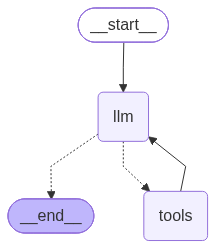

In [ ]:
builder = StateGraph(DeepAgentState)
builder.add_node("llm", no_llm)
builder.add_node("tools", no_tools)

builder.add_edge(START, "llm")
builder.add_conditional_edges("llm", should_continue, {"tools": "tools", END: END})
builder.add_edge("tools", "llm")

deep_agent = builder.compile()
display_graph(deep_agent)

## 8.6 Executando o deep agent

Mesma tarefa da seção 2, agora com os quatro componentes disponíveis.

In [ ]:
resultado_deep = deep_agent.invoke({
    "messages": [HumanMessage(content=TAREFA_LONGA)],
    "todos": [],
    "files": {},
})

print(f"Mensagens no histórico: {len(resultado_deep['messages'])}")
print(f"Tokens aproximados no contexto final: {contar_tokens_aproximado(resultado_deep['messages'])}")
print(f"Arquivos produzidos: {len(resultado_deep['files'])}")

Mensagens no histórico: 31

Tokens aproximados no contexto final: 4127

Arquivos produzidos: 4

## 8.7 O traço de execução

Vale olhar o estado final por partes. Primeiro a lista de tarefas — o plano que o agente escreveu e foi
atualizando.

In [ ]:
print("=== LISTA DE TAREFAS FINAL ===")
for item in resultado_deep["todos"]:
    marca = {"concluida": "[x]", "em_andamento": "[~]", "pendente": "[ ]"}.get(item["status"], "[?]")
    print(f"{marca} {item['descricao']}")

=== LISTA DE TAREFAS FINAL ===

Consultar o progresso da aluna Ana.

Listar os módulos restantes para a aluna Ana.

Carregar o material de cada módulo em um arquivo separado.

Delegar a leitura e fichamento do material de cada módulo ao subagente especializado.

[~] Ler as fichas produzidas pelo subagente para cada módulo.

[ ] Produzir uma síntese indicando por onde a aluna deve começar.

In [ ]:
print("=== SISTEMA DE ARQUIVOS FINAL ===")
for caminho in sorted(resultado_deep["files"]):
    conteudo = resultado_deep["files"][caminho]
    print(f"{caminho:28} {len(conteudo):6} caracteres")

total_arquivos = sum(len(c) for c in resultado_deep["files"].values())
print(f"\nTotal fora do contexto: {total_arquivos} caracteres (~{total_arquivos // 4} tokens)")

=== SISTEMA DE ARQUIVOS FINAL ===

/fichas/a7.md                   481 caracteres

/fichas/a8.md                   583 caracteres

/material/a7.md                2058 caracteres

/material/a8.md                2045 caracteres

Total fora do contexto: 5167 caracteres (~1291 tokens)

In [ ]:
print("=== SEQUÊNCIA DE CHAMADAS ===")
passo = 0
for m in resultado_deep["messages"]:
    if isinstance(m, AIMessage) and m.tool_calls:
        passo += 1
        nomes = ", ".join(c["name"] for c in m.tool_calls)
        print(f"{passo:2}. {nomes}")

=== SEQUÊNCIA DE CHAMADAS ===

1. write_todos, consultar_progresso_aluno

2. write_todos, consultar_modulos_restantes

3. write_todos, consultar_modulos_restantes

4. write_todos, carregar_material_em_arquivo

...

6. write_todos, read_file

7. read_file

8. write_todos, carregar_material_em_arquivo

9. write_todos, delegar_leitura

10. write_todos, read_file

In [ ]:
print(Markdown(str(resultado_deep["messages"][-1].content)))

A ficha do módulo A8 foi lida com sucesso. Vamos carregar o material do próximo módulo, "Raciocínio em agentes"    
(A9).                                                                                                              

Aqui está um resumo da ficha de estudo para o módulo A8:                                                           

 • Skills são instruções sobre procedimentos que evitam o inchaço do prompt de sistema.                            
 • Anatomia da skill: Inclui metadados (nome e descrição), corpo com instruções passo a passo, e recursos          
   adicionais.                                                                                                     
 • Progressive disclosure: Descoberta apenas com nome/descrição, ativação carrega o corpo completo, recursos lidos 
   conforme necessário.                                                                                            
 • Boas práticas na escrita de skills: Descrições precisas da aplicabilidade e instruções focadas em procedimentos 
   simples.                                                                                                        
 • Skills respondem 'como' fazer algo, enquanto tools respondem 'o que' pode ser feito e MCP 'onde' se pode        
   acessar.                                                                                                        

Agora, vamos carregar o material do módulo A9.

## Discussão

O traço acima é o que vale mostrar em sala. Três coisas aparecem nele.

O plano é um **artefato**, não uma narrativa perdida no histórico: dá para inspecioná-lo a qualquer momento
da execução, e é dele que sairia uma barra de progresso ou um pedido de aprovação humana.

O total de caracteres em arquivo, comparado com os tokens do contexto final, mostra a assimetria: o agente
processou muito mais informação do que carregou. Essa é a definição operacional de descarregamento.

E a sequência de chamadas mostra o padrão que o prompt induziu — planejar, levantar informação estrutural,
carregar e delegar módulo a módulo, atualizar o plano, sintetizar.

Uma limitação honesta desta implementação: o `no_tools` executa as chamadas **sequencialmente**, mesmo quando
o LLM pede várias de uma vez. Delegar cinco leituras em paralelo reduziria bastante a latência, e é o que
implementações reais fazem.

# 9. O mesmo com a biblioteca `deepagents`

Tudo o que construímos nas seções 4 a 8 existe pronto na biblioteca `deepagents`, mantida pela LangChain. Ela
é descrita como um *agent harness*: o mesmo loop de tool calling, com capacidades embutidas.

A construção manual não foi desperdício — é o que permite saber o que a biblioteca faz por baixo, e o que
ajustar quando o padrão não servir. Mas para uso prático, o caminho é este.

> A biblioteca evolui rápido. Se a assinatura abaixo divergir, consulte
> `docs.langchain.com/oss/python/deepagents`.

In [ ]:
# Descomente para instalar.
%pip install -U deepagents

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.0/681.0 kB 556.6 kB/s  0:00:00eta 0:00:01
  Attempting uninstall: langsmith
    Found existing installation: langsmith 0.10.1
    Uninstalling langsmith-0.10.1:━━━━━━━━━━━━━━ 0/2 [langsmith]
      Successfully uninstalled langsmith-0.10.1━ 0/2 [langsmith]
  Attempting uninstall: deepagents━━━━━━━━━━━━━━ 0/2 [langsmith]
    Found existing installation: deepagents 0.6.120/2 [langsmith]
    Uninstalling deepagents-0.6.12:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [deepagents]
      Successfully uninstalled deepagents-0.6.12━━━━━━━━━━━━━━━━━━ 1/2 [deepagents]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [deepagents]2 [deepagents]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


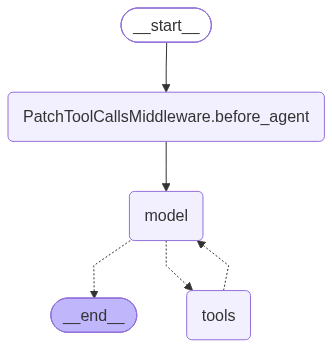

In [ ]:
from deepagents import create_deep_agent

agente_pronto = create_deep_agent(
    model=llm,
    tools=[consultar_progresso_aluno, consultar_modulos_restantes, calcular_carga_total],
    system_prompt=(
        "Você é o assistente do curso de agentes com LLMs. "
        "Planeje antes de agir, grave resultados longos em arquivos e delegue leituras a subagentes."
    ),
)

display_graph(agente_pronto)

In [ ]:
resultado_pronto = agente_pronto.invoke({"messages": [HumanMessage(content=TAREFA_LONGA)]})

print(f"Mensagens: {len(resultado_pronto['messages'])}")
print(f"Arquivos:  {list((resultado_pronto.get('files') or {}).keys())}")

Mensagens: 8

Arquivos:  []

## Discussão

Cinco linhas substituem as cerca de cento e cinquenta que escrevemos. Vale saber o que vem embutido: as tools
de planejamento e de arquivo já estão lá, o prompt de sistema padrão do harness é acrescentado ao que você
passa, e existe um mecanismo de subagentes configurável.

Duas capacidades da biblioteca que não implementamos e que valem menção. Há um **sistema de permissões por
caminho**, que permite negar escrita em rotas específicas — é a resposta prática ao modelo de confiança
irrestrita no LLM, e conecta com as preocupações de segurança do notebook de MCP. E há **descarregamento
automático**: quando o resultado de uma tool passa de um limite de tokens, ele é gravado no sistema de
arquivos e substituído por uma prévia truncada, sem que o agente precise decidir nada.

# 10. Backends e persistência

O sistema de arquivos que implementamos vive no estado do grafo. Isso significa **persistência de curto
prazo, no escopo da thread**: quando a conversa termina, os arquivos somem.

Na biblioteca, esse comportamento é o padrão (`StateBackend`), mas é apenas um entre vários. O sistema de
arquivos virou uma abstração plugável: qualquer backend que implemente o protocolo esperado funciona, e
trocar de backend não muda nada no agente.

| Backend | Onde os arquivos vivem | Sobrevive à sessão? |
|---|---|---|
| `StateBackend` (padrão) | Estado do grafo | Não |
| `FilesystemBackend` | Disco real, sob um `root_dir` | Sim |
| `StoreBackend` | Store do LangGraph | Sim, entre threads |
| `CompositeBackend` | Roteia caminhos para backends diferentes | Depende da rota |

## 10.1 O padrão canônico: rotas com escopos diferentes

O `CompositeBackend` escolhe o backend por prefixo de caminho. O uso mais comum é persistir `/memories/`
entre conversas e manter todo o resto no escopo da thread:

```python
CompositeBackend(
    default=StateBackend(),
    routes={"/memories/": StoreBackend()},
)
```

O que isso significa é notável: **o mesmo sistema de arquivos abriga memória de curto e de longo prazo,
separadas apenas por caminho**. `/fichas/a7.md` morre com a sessão; `/memories/preferencias.md` sobrevive.

Do ponto de vista do agente, é tudo `read_file` e `write_file` — a distinção fica na infraestrutura,
invisível para o modelo. Essa é a ponte direta para a próxima aula, sobre memória em agentes.

In [ ]:
# Demonstração conceitual do roteamento por prefixo, sem depender da biblioteca.
ROTAS = {"/memories/": "StoreBackend (persiste entre sessões)"}
PADRAO = "StateBackend (efêmero, escopo da thread)"


def escolher_backend(caminho: str) -> str:
    """Correspondência por prefixo mais longo, como faz o CompositeBackend."""
    melhor_prefixo = ""
    for prefixo in ROTAS:
        if caminho.startswith(prefixo) and len(prefixo) > len(melhor_prefixo):
            melhor_prefixo = prefixo
    return ROTAS.get(melhor_prefixo, PADRAO)


for caminho in ["/fichas/a7.md", "/material/a8.md", "/memories/preferencias.md", "/memories/perfil/ana.json"]:
    print(f"{caminho:32} → {escolher_backend(caminho)}")

/fichas/a7.md                    → StateBackend (efêmero, escopo da thread)

/material/a8.md                  → StateBackend (efêmero, escopo da thread)

/memories/preferencias.md        → StoreBackend (persiste entre sessões)

/memories/perfil/ana.json        → StoreBackend (persiste entre sessões)

## Discussão

Um alerta que vale registrar. Quando o `StoreBackend` é usado sem um namespace explícito, o padrão legado
escopa o armazenamento pelo identificador do assistente — o que significa que **todos os usuários do mesmo
assistente compartilham os mesmos arquivos**.

Em um agente de curso, isso significaria a Ana lendo as anotações do Bruno. Não é um detalhe de configuração:
é vazamento entre usuários acontecendo por omissão. O namespace deve ser definido explicitamente, tipicamente
a partir do identificador do usuário.

# 11. Comparando agente raso e deep agent

Agora podemos responder com números a pergunta da seção 2.

In [ ]:
def resumir_execucao(nome: str, mensagens: List[BaseMessage], arquivos: Optional[Dict[str, str]] = None) -> dict:
    arquivos = arquivos or {}
    chamadas_llm = sum(1 for m in mensagens if isinstance(m, AIMessage))
    chamadas_tool = sum(len(m.tool_calls) for m in mensagens if isinstance(m, AIMessage) and m.tool_calls)

    return {
        "agente": nome,
        "chamadas_llm": chamadas_llm,
        "chamadas_tool": chamadas_tool,
        "tokens_contexto_final": contar_tokens_aproximado(mensagens),
        "caracteres_em_arquivo": sum(len(c) for c in arquivos.values()),
        "artefatos": len(arquivos),
    }


comparacao = [
    resumir_execucao("raso", mensagens_raso),
    resumir_execucao("deep", resultado_deep["messages"], resultado_deep["files"]),
]

for linha in comparacao:
    print_json(linha)

{
  "agente": "raso",
  "chamadas_llm": 8,
  "chamadas_tool": 7,
  "tokens_contexto_final": 3700,
  "caracteres_em_arquivo": 0,
  "artefatos": 0
}

{
  "agente": "deep",
  "chamadas_llm": 11,
  "chamadas_tool": 19,
  "tokens_contexto_final": 4127,
  "caracteres_em_arquivo": 5167,
  "artefatos": 4
}

In [ ]:
raso, deep = comparacao

print(f"{'Métrica':28} {'Raso':>10} {'Deep':>10}")
print("-" * 50)
for chave in ["chamadas_llm", "chamadas_tool", "tokens_contexto_final", "caracteres_em_arquivo", "artefatos"]:
    print(f"{chave:28} {raso[chave]:>10} {deep[chave]:>10}")

if deep["tokens_contexto_final"] < raso["tokens_contexto_final"]:
    reducao = 100 - 100 * deep["tokens_contexto_final"] // max(raso["tokens_contexto_final"], 1)
    print(f"\nRedução no contexto final: {reducao}%")

Métrica                            Raso       Deep

--------------------------------------------------

chamadas_llm                          8         11

chamadas_tool                         7         19

tokens_contexto_final              3700       4127

caracteres_em_arquivo                 0       5167

artefatos                             0          4

## 11.1 A comparação conceitual

| | Agente raso | Deep agent |
|---|---|---|
| Plano | Implícito no histórico | Explícito, no estado, revisável |
| Memória | Só a janela de contexto | Sistema de arquivos, sob demanda |
| Subtarefas | No mesmo contexto | Delegadas com contexto isolado |
| Instruções | Prompt curto | Prompt procedural extenso |
| Custo por passo | Baixo | Mais alto (mais chamadas) |
| Contexto ao longo do tempo | Cresce sem limite | Controlado |
| Melhor caso | Tarefas de poucos passos | Tarefas de longo horizonte |

Um jeito simples de decidir entre eles:

- **A tarefa tem poucos passos e o resultado de cada um cabe no contexto?** → ReAct simples.
- **A sequência de passos é o problema, mas o volume não é?** → Plan-and-Execute do notebook anterior.
- **O volume de informação intermediária é o problema?** → sistema de arquivos.
- **Subtarefas produzem muito ruído que o coordenador não precisa ver?** → subagentes.
- **Tudo isso ao mesmo tempo, e a tarefa dura dezenas de passos?** → deep agent.

Nada impede combinar: o deep agent do notebook usa Plan-and-Execute no macro e ReAct dentro de cada
subagente.

## Discussão

Os números merecem leitura cuidadosa, e provavelmente vão mostrar duas coisas ao mesmo tempo: **menos tokens
no contexto final** e **mais chamadas de LLM**. As duas são esperadas.

O deep agent gasta chamadas para planejar, para gravar, para delegar e para reler. Ele troca *tokens
acumulados* por *número de chamadas*. Em uma tarefa curta essa troca é ruim — o andaime custa mais do que
economiza. Em uma tarefa longa ela é o que torna a execução possível.

Vale também dizer o que esta comparação **não** mede: qualidade. Nós comparamos custo e volume, não se o guia
produzido é melhor. Avaliar qualidade de saída em tarefas longas é difícil e é assunto do módulo de avaliação
de sistemas multiagentes. Um exercício útil, se quiser ir além: escrever uma rubrica de cinco critérios e
pontuar as duas saídas manualmente.

# 12. Boas práticas

## 12.1 Comece pelo ReAct

O agente simples do notebook de Ferramentas continua sendo o padrão adequado para a maioria das tarefas. Deep
agents existem para tarefas longas — usar o padrão em uma tarefa de três passos só adiciona custo, latência e
imprevisibilidade.

## 12.2 Descarregue o que é grande, não o que é pequeno

Gravar em arquivo um resultado de 200 caracteres custa uma chamada de escrita e outra de leitura para
economizar 200 caracteres. Descarregamento compensa quando o conteúdo é volumoso e usado poucas vezes.

## 12.3 Projete o conjunto de tools, não só o prompt

Deixar disponível uma tool que devolve texto longo direto para a conversa anula todo o mecanismo de
descarregamento — o agente vai usá-la, porque é mais simples. O que você **não** oferece é tão importante
quanto o que oferece.

## 12.4 Delegue por contexto, não por organização

Se a subtarefa produz pouco ruído, um subagente é overhead: mais uma chamada, mais um prompt, mais uma
oportunidade de perder informação no resumo. Delegue quando o volume intermediário justificar o isolamento.

## 12.5 Sempre limite o número de passos

Um deep agent com arquivos demora muito mais para estourar a janela do que um agente raso — o que significa
que um laço improdutivo pode rodar por muito tempo antes de falhar. O limite explícito de passos deixa de ser
proteção contra estouro e passa a ser proteção contra custo.

## 12.6 Trate o plano como artefato auditável

O `todos` no estado é o melhor ponto de observabilidade do agente. Logue-o a cada atualização, exiba-o ao
usuário, e considere exigir aprovação humana antes de executar passos sensíveis.

# 13. Exercícios de fixação

## Exercício 1 — Descarregamento automático

Escreva uma função `executar_com_descarregamento(tool, argumentos, limite=600)` que execute uma tool comum e,
se o resultado passar de `limite` caracteres, grave-o em um arquivo e devolva um `Command` com a prévia
truncada, em vez do texto completo. Aplique-a a `consultar_material_modulo` e verifique que o agente não
precisa mais de uma tool especial por tipo de conteúdo.

In [ ]:
# Escreva sua solução aqui.

## Exercício 2 — `write_todos` que valida

Modifique `write_todos` para rejeitar a marcação de uma tarefa como `concluida` quando ela estava `pendente`
na versão anterior da lista, sem ter passado por `em_andamento`. A tool deve devolver uma `ToolMessage` de
erro explicando a regra. Rode o agente e observe se ele se adapta.

In [ ]:
# Escreva sua solução aqui.

## Exercício 3 — Um segundo subagente

Crie um subagente `sintetizador`, que lê todas as fichas do diretório `/fichas/` e produz o guia final,
gravando-o em `/guia.md`. Ajuste o prompt de sistema para que o coordenador delegue também a síntese. Compare
o contexto final do coordenador antes e depois dessa mudança.

In [ ]:
# Escreva sua solução aqui.

## Exercício 4 — `edit_file`

Implemente uma tool `edit_file(caminho, texto_antigo, texto_novo)` que substitua uma ocorrência dentro de um
arquivo existente, devolvendo erro se o texto não for encontrado ou se aparecer mais de uma vez. Explique, em
uma frase, por que essa tool é preferível a `write_file` quando o arquivo é grande.

In [ ]:
# Escreva sua solução aqui.

## Exercício 5 — Permissões por caminho

Acrescente ao nó de tools uma verificação de permissões: `write_file` deve recusar gravação em caminhos que
comecem com `/material/`, devolvendo uma `ToolMessage` de erro. Relacione essa proteção com o princípio do
menor privilégio visto no notebook de MCP.

In [ ]:
# Escreva sua solução aqui.

## Exercício 6 — Delegação em paralelo

O nó `no_tools` executa as chamadas sequencialmente. Modifique-o para executar em paralelo as chamadas de
`delegar_leitura` quando o LLM pedir várias na mesma resposta. Meça a diferença de tempo total com `time`.

In [ ]:
# Escreva sua solução aqui.

## Exercício 7 — Quando não usar um deep agent

Escolha uma das tarefas dos notebooks anteriores — por exemplo, responder qual a situação de um aluno no
curso — e argumente, em um parágrafo, por que aplicar o padrão deep agent a ela seria uma escolha ruim. Cite
pelo menos dois custos concretos.

In [ ]:
# Escreva sua resposta aqui.

# 14. Resumo da aula

Neste notebook, vimos os quatro componentes de um deep agent:

- **Prompt de sistema**: instruções procedurais que dizem quando planejar, gravar, delegar e ler — é o
  conhecimento procedural do notebook de Skills aplicado ao próprio agente.
- **Ferramenta de planejamento**: `write_todos` transforma o plano em campo estruturado do estado, inspecionável
  e revisável, em vez de texto perdido no histórico.
- **Sistema de arquivos virtual**: um dicionário no estado, com reducer próprio, que permite descarregar
  resultados volumosos e relê-los sob demanda.
- **Subagentes**: delegação com contexto isolado e sistema de arquivos compartilhado — só o resultado volta ao
  coordenador.

O loop permanece sendo o mesmo ReAct do notebook de Ferramentas. Três dos quatro componentes são apenas tools
que o loop pode chamar. O que muda não é a inteligência do agente, e sim a estrutura em volta dele.

O princípio que unifica os quatro é o context engineering: a janela é um recurso finito, e cada componente
implementa uma estratégia de gestão — escrever, selecionar, comprimir, isolar.

E a escolha continua sendo uma troca. O deep agent gasta mais chamadas de LLM para manter o contexto sob
controle. Em tarefas curtas, o andaime custa mais do que economiza; em tarefas longas, é o que torna a
execução possível.

## 14.1 Checklist de compreensão

Antes de avançar, verifique se você consegue responder:

1. Por que um agente ReAct simples degrada em uma tarefa de leitura de muitos documentos, mesmo que o
   raciocínio esteja correto?
2. O que uma tool ganha ao devolver `Command` em vez de uma string?
3. Por que `tool_call_id` e `state` não aparecem no schema que o LLM enxerga?
4. Por que o campo `files` precisa de um reducer, e o que aconteceria sem ele?
5. Por que o descarregamento de contexto só funciona se a tool gravar o conteúdo **diretamente**, sem passar
   pela conversa?
6. Subagentes isolam o quê, exatamente — e o que continua compartilhado?
7. Qual é o argumento para delegar em um deep agent, e como ele difere do argumento do padrão Supervisor?
8. Em que situação você escolheria um agente ReAct simples em vez de um deep agent?

## 14.2 Próximos passos

A partir daqui, você pode evoluir os agentes deste notebook para incluir:

- descarregamento automático por limite de tokens, sem tool especializada;
- delegação paralela de subagentes, com medição de latência;
- permissões por caminho no sistema de arquivos;
- persistência entre sessões com `StoreBackend`, separando `/memories/` do restante;
- métricas de custo real em tokens, com o tokenizador do provedor em vez da estimativa deste notebook;
- avaliação de qualidade da saída, com rubrica, e não apenas de custo;
- integração das skills e tools MCP dos notebooks anteriores ao harness.

O próximo notebook trata de **memória em agentes**, e retoma diretamente a seção 10: o sistema de arquivos
como substrato de memória de curto e longo prazo.

# 15. Referências

- Yao et al. — ReAct: Synergizing Reasoning and Acting in Language Models
- Sumers et al. — Cognitive Architectures for Language Agents (CoALA)
- METR — Measuring AI Ability to Complete Long Tasks
- Anthropic — Building a Multi-Agent Research System
- LangChain — Deep Agents, documentação oficial: https://docs.langchain.com/oss/python/deepagents
- LangChain — Backends do sistema de arquivos: https://docs.langchain.com/oss/python/deepagents/backends
- LangChain — Repositório deepagents: https://github.com/langchain-ai/deepagents
- LangChain — Deep Agents from Scratch: https://github.com/langchain-ai/deep-agents-from-scratch
- Notebooks anteriores da sequência: N2 (Introdução a LangGraph), N4 (Ferramentas), N6 (Skills), N8 (Planning)